>0 f([-0.78937549]) = 0.62311
>1 f([-0.6315004]) = 0.39879
>2 f([-0.50520032]) = 0.25523
>3 f([-0.40416025]) = 0.16335
>4 f([-0.3233282]) = 0.10454
>5 f([-0.25866256]) = 0.06691
>6 f([-0.20693005]) = 0.04282
>7 f([-0.16554404]) = 0.02740
>8 f([-0.13243523]) = 0.01754
>9 f([-0.10594819]) = 0.01123
>10 f([-0.08475855]) = 0.00718
>11 f([-0.06780684]) = 0.00460
>12 f([-0.05424547]) = 0.00294
>13 f([-0.04339638]) = 0.00188
>14 f([-0.0347171]) = 0.00121
>15 f([-0.02777368]) = 0.00077
>16 f([-0.02221894]) = 0.00049
>17 f([-0.01777516]) = 0.00032
>18 f([-0.01422012]) = 0.00020
>19 f([-0.0113761]) = 0.00013
>20 f([-0.00910088]) = 0.00008
>21 f([-0.0072807]) = 0.00005
>22 f([-0.00582456]) = 0.00003
>23 f([-0.00465965]) = 0.00002
>24 f([-0.00372772]) = 0.00001
>25 f([-0.00298218]) = 0.00001
>26 f([-0.00238574]) = 0.00001
>27 f([-0.00190859]) = 0.00000
>28 f([-0.00152687]) = 0.00000
>29 f([-0.0012215]) = 0.00000


C:\Users\Johan\AppData\Local\Temp\ipykernel_22456\3927904572.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>%d f(%s) = %.5f' % (i, solution, solution_eval))


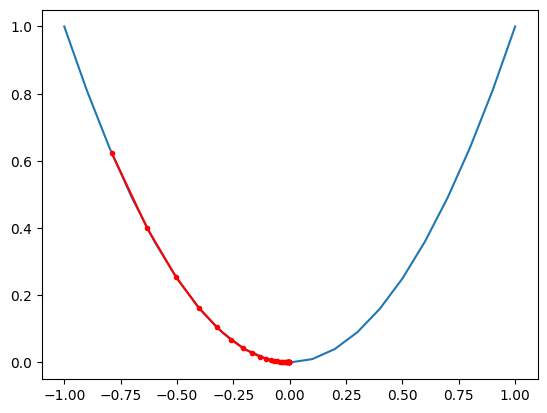

In [11]:
from numpy import asarray # Used to convert normal Python lists into NumPy arrays (needed for vector operations)
from numpy import arange # Used to generate evenly spaced numbers (like range but supports decimals)
from numpy.random import rand # Generated random numbers between 0 and 1
from matplotlib import pyplot # Library used for plotting graphs

# objective functions
def objective(x):
    return x**2.0 # Function we want to minimize -> f(x) = x^2 (a bowl-shaped curve, minimum at x = 0)

# derivative of objective function
def derivative(x):
    return x * 2.0 # Derivative of x^2 is 2x -> tells slope (direction + steepness)

# gradient descent algorithm
def gradient_descent(objective, derivative, bounds, n_iter, step_size):
  solutions, scores = list(), list()
  solution = bounds[:,0] + rand(len(bounds)) * (bounds[:,1] - bounds[:,0])
  # Step-by-step:
  # bounds[:, 0] -> lower bound (e.g., -1)
  # bounds[:, 1] -> upper bound (e.g., 1)
  # rand(...) -> random number between 0 and 1
  # So this picks a random starting point between -1 and 1
  # IMPORTANT: Gradient descent usually starts from a random guess

  #run the gradient descent
  for i in range(n_iter): # Loop runs 'n_iter' times (each loop = one step downhill)
    gradient = derivative(solution)
    # Compute slope at current point
    # If slope is positive -> move left
    # If slope is negative -> move right

    solution = solution - step_size * gradient
    # Core idea of gradient descent:
    # new_x = old_x - (learning_rate * slope)
    # We subtract because we want to move "downhill"
    # step_size controls how big each step is

    solution_eval = objective(solution)
    # Evaluate how good this solution is (calculate f(x))

    solutions.append(solution)
    # Store current x value

    scores.append(solution_eval)
    # Store corresponding function value

    print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
    # Print progress:
    # i -> iteration number
    # solution -> current x
    # solution_eval -> current f(x)

  return[solutions, scores]
  # Return all visited points and their values

# define range for input
bounds = asarray([[-1.0, 1.0]])
# Search space -> x can be between -1 and 1

# define the total iterations
n_iter = 30
# Number of steps gradient descent will take
# More iterations -> better  change to reach minimum

# define the step size
step_size = 0.1
# Learning rate:
# Small -> slow but stable
# Large -> fast but may overshoot

# perform the gradient descent search
solutions, scores = gradient_descent(objective, derivative, bounds, n_iter, step_size)
# Run algorithm and collect all steps taken

# sample input range uniformly at 0.1 increments
inputs = arange(bounds[0,0], bounds[0,1]+0.1, 0.1)
# Creates values like: -1.0, -0.9, ..., 1.0
# Used for plotting the actual function curve

# compute targets
results = objective(inputs)
# Apply f(x) = x^2 to all input values to get curve points

# create a line plot of input vs result
pyplot.plot(inputs,results)
# Plot the actual function curve (parabola)

# plot the solutions found
pyplot.plot(solutions , scores, '.-', color='red')
# Plot the path taken by the gradient descent
# '.' -> points

# show the plot
pyplot.show()
# Display the final graph

In [13]:
# Extra activity
# try to create a dictornary containing name id and salary of employee and then load the data into a dataframe and finally display the top 5 values of that dataframe

import pandas as pd
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'ID': [101, 102, 103, 104, 105],
    'Salary': [50000, 60000, 55000, 70000, 65000]
}

df = pd.DataFrame(data)

# Display the top 5 values
df.tail(2)

,Name,ID,Salary
3,David,104,70000
4,Eve,105,65000
